## 6. Lead-Lag Correlation Analysis

,target,variable,lag_quarters,correlation,n_obs,abs_correlation
203,cpi_yoy,inflation_expectations_business,1,0.7407,123,0.7407
14,cpi_yoy,trimmed_mean_cpi_qoq,1,0.7173,123,0.7173
6,cpi_yoy,cpi_qoq,2,0.6704,122,0.6704
32,cpi_yoy,headline_trimmed_mean_yoy_gap,1,0.6592,123,0.6592
105,cpi_yoy,ppi_growth,2,0.5556,107,0.5556
96,cpi_yoy,producer_price_index,2,0.5550,107,0.5550
60,cpi_yoy,cash_rate,2,0.5112,121,0.5112
69,cpi_yoy,cash_rate_change,2,0.5112,121,0.5112
196,cpi_yoy,household_spending_growth,3,0.4941,50,0.4941
187,cpi_yoy,household_spending,3,0.4815,50,0.4815


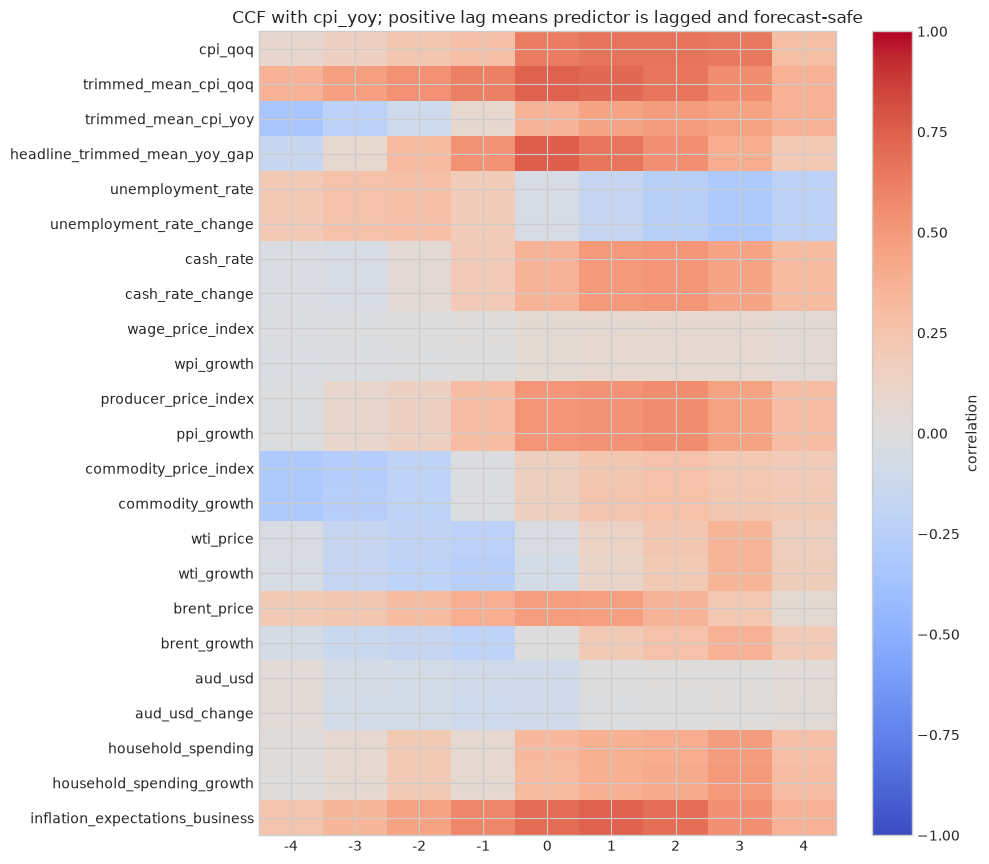

In [8]:
integration_lookup = dict(zip(stationarity['variable'], stationarity['integration_order']))

def stationary_series(column: str) -> pd.Series:
    series = clean_series(column)
    order = integration_lookup.get(column, 'unclear')
    if order == 'I(0)':
        result = series
    elif order == 'I(2)':
        result = series.diff().diff()
    else:
        log_diff = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
        result = log_diff if log_diff.notna().sum() >= 12 else series.diff()
    return result.replace([np.inf, -np.inf], np.nan).dropna()


def correlation_columns_for_target(target: str, include_cpi_diagnostics: bool) -> list[str]:
    cpi_diagnostics = [
        column for column in CPI_DIAGNOSTIC_BASE_COLS
        if include_cpi_diagnostics and column in df_model.columns and column != target
    ]
    return cpi_diagnostics + EXTERNAL_BASE_COLS


def compute_lead_lag_correlation(
    target: str,
    predictor_columns: list[str],
    max_lag: int = MAX_LAG,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    target_stationary_values = stationary_series(target).rename(target)
    ccf_rows = []
    for column in predictor_columns:
        x = stationary_series(column).rename(column)
        for lag in range(-max_lag, max_lag + 1):
            aligned = pd.concat([target_stationary_values, x.shift(lag)], axis=1).dropna()
            corr = aligned[target].corr(aligned[column]) if len(aligned) >= 12 else np.nan
            ccf_rows.append({
                'target': target,
                'variable': column,
                'lag_quarters': lag,
                'correlation': corr,
                'n_obs': len(aligned),
            })

    ccf_frame = pd.DataFrame(ccf_rows)
    positive_lag_ccf = ccf_frame.loc[ccf_frame['lag_quarters'] > 0].dropna(subset=['correlation']).copy()
    best_predictive = (
        positive_lag_ccf.assign(abs_correlation=lambda frame: frame['correlation'].abs())
        .sort_values(['variable', 'abs_correlation'], ascending=[True, False])
        .groupby('variable', as_index=False)
        .head(1)
        .sort_values('abs_correlation', ascending=False)
    )
    return ccf_frame, best_predictive, target_stationary_values


def display_lead_lag_correlation(
    target: str,
    predictor_columns: list[str],
    ccf_frame: pd.DataFrame,
    best_predictive: pd.DataFrame,
) -> None:
    display(best_predictive.round(4))

    heatmap_data = ccf_frame.pivot(index='variable', columns='lag_quarters', values='correlation').loc[predictor_columns]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(predictor_columns))))
    image = ax.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)
    ax.set_title(f'CCF with {target}; positive lag means predictor is lagged and forecast-safe')
    fig.colorbar(image, ax=ax, label='correlation')
    fig.tight_layout()
    plt.show()


CORRELATION_BASE_COLS = correlation_columns_for_target(TARGET, include_cpi_diagnostics=True)
ccf, best_predictive_ccf, target_stationary = compute_lead_lag_correlation(TARGET, CORRELATION_BASE_COLS)
display_lead_lag_correlation(TARGET, CORRELATION_BASE_COLS, ccf, best_predictive_ccf)